Device is cpu
 Epoch 1/2 | Loss : 0.3717 
 Epoch 2/2 | Loss : 0.0919 
Training Complete
Accuracy 98.94459102902374


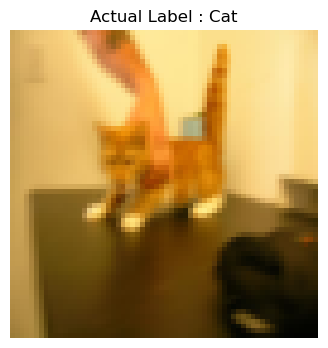

User picked image index 0
Actual Label: Cat
Model Prediction: Cat


In [15]:
import torch 
import torch.nn as nn
import torch.optim as optim 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device is", device)

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    "PetImages/train",
    transform=transform    
)

test_data = datasets.ImageFolder(
    "PetImages/test",
    transform=transform    
)

class_names = train_data.classes

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=True
)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3,32,3),
            nn.ReLU(), 
            nn.MaxPool2d(2), 
            nn.Conv2d(32,64,3),
            nn.ReLU(), 
            nn.MaxPool2d(2), 
            nn.Flatten(),
            nn.Linear(64*14*14,128), 
            nn.ReLU(),
            nn.Linear(128,10)      
        )

    def forward(self,x):
        return self.net(x)

model = CNN().to(device)

loss_fn = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 2
for epoch in range(epochs): 
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss=loss_fn(outputs,labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f" Epoch {epoch+1}/{epochs} | Loss : {loss.item():.4f} ")
    
print("Training Complete")

model.eval()
correct=0
total=0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1) 

        correct += (predictions == labels).sum().item() 
        total += labels.size(0)

accuracy = 100*correct/total 
print("Accuracy", accuracy)

torch.save(model.state_dict(), "catdog.pth")

index = 0 
image, true_label = test_data[index]
plt.figure(figsize=(4,4))
plt.imshow(image.squeeze().permute(1,2,0))
plt.title(f"Actual Label : {class_names[true_label]}")
plt.axis("off")
plt.show() 

image = image.unsqueeze(0).to(device)
with torch.no_grad(): 
    output = model(image)
    prediction = output.argmax(dim=1).item()

print("User picked image index", index) 
print("Actual Label:", class_names[true_label])
print("Model Prediction:", class_names[prediction])